# Model validation
Once the mapping is learned, one can project the entire sc dataset into all spots → this yields a reconstructed spatial dataset that allows for two possibilities:  

- Firstly, I can explore the full transcriptome profile of spots, obtaining expression levels for all genes that are absent from the ST data.  
- Secondly, I can adjust the expression profile for the sequenced genes in the spatial data as well (especially for poorly detected genes or low-quality spots).  

This raises the question of when to impute also sequenced genes in the ST data.  

Tangram is a model that, per se, is intended to be trained on individual experiments: the user is expected to provide coherent scRNA-seq and ST assays and to adopt Tangram to enhance the spatial data. This has two main consequences:  

- Mapping quality can be directly assessed on training genes with specific metrics such as:  
  - the score (which, importantly, is the objective and thus optimized for),  
  - the sparsity-weighted score,  
  - mapping entropy (even at the single-cell level), and  
  - the AUC score.  

- Overfitting can only be understood in the sense that non-training genes are not predicted as well as training (aligned) genes for the given datasets; the mapping is not expected to generalize well to other external datasets unless these are very similar in terms of tissue composition to those used in training.  

To evaluate this last aspect, one can preemptively leave out a portion of genes for validation:  

- Exclude them from training,  
- Project the learned cells onto these genes, and  
- Reconstruct their spatial profiles.  

From there, one can compute the similarity with the true profile.


# Setup

In [1]:
%cd ..
import tangramlit as tg

C:\Users\enric\tangram


C:\Users\enric\tangram\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
C:\Users\enric\tangram\.venv\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\enric\tangram\.venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import scanpy as sc

In [ ]:
!uv pip install winshell

In [ ]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")

# Data Loading

In [3]:
## Load pre-processed datasets
path = "H:/Il mio Drive"
adata_sc = sc.read_h5ad(path + "/data_tangram/counts100k_filt_pp_train_genes.h5ad")
adata_sc

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe', 'sparsity'
    uns: 'hvg', 'neighbors', 'pca', 'training_genes', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
adata_st = sc.read_h5ad(path + "/data_tangram/slice200_pp.h5ad")
adata_st

AnnData object with n_obs × n_vars = 2133 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

# Deterministic Mapping

Tangram mapping is probabilistic:  

- **Gene imputation:** all cells (or a filtered subset) are used to reconstruct all spots → expanding the ST data profile to the whole transcriptome with \(G^\).  

- **Final mapping matrix and annotation transfer** (see next slides) are probabilistic: for each cell, we have the probability that it is located in spot \(j\).  

For single-cell resolution spatial technologies, it can make sense to perform a **deterministic one-to-one mapping**, which can occur in two ways:  

- **Cell-to-spot:** each cell is assigned to the most probable spot (from the probability distribution defined in the rows of $M$).  
- **Spot-to-cell:** each spot is assigned to the largest contributing cell, recalling that each column of the matrix $M$ is not inherently a probability density function but rather a composition array where each value represents the contribution of the cell (i) to spot (j).

*NOTE*: The entries of the unfiltered matrix $M$ sum to $n_{cells}$ by definition, thus each col-sum approaches $\frac{n_{cells}}{n_{spots}}$ as the $KL$ term acts


## Vanilla mode

In [5]:
ad_map_vanilla, mapper_vanilla, data_vanilla = tg.map_cells_to_space(
        adata_sc, 
        adata_st, 
        mode='vanilla',
        learning_rate=0.1,
        num_epochs=200,
        lambda_d=1e2,
        lambda_g1=1,
        lambda_g2=1,
        lambda_r=1e-6,
        lambda_l1=2e-9,
        lambda_l2=2e-9,
        random_state=42,
        )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 164 M  | n/a  
---------------------------------------------------------
164 M     Trainable params
0         Non-trainable params
164 M     Total params
659.839   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/200 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   0%|▎                                                                        | 1/200 [00:11<39:08, 11.80s/it]

Epoch 0: {'Total loss': 0.11898645758628845, 'Score': 0.5169236660003662, 'KL divergence': 1.1752592399716377e-05}


Trainig:  50%|███████████████████████████████████▊                                   | 101/200 [13:48<12:15,  7.42s/it]

Epoch 100: {'Total loss': -0.25694912672042847, 'Score': 0.6169785857200623, 'KL divergence': 2.939486876130104e-06}


Trainig: 100%|███████████████████████████████████████████████████████████████████████| 200/200 [27:28<00:00,  8.24s/it]


In [6]:
# Get spot-cell pairs dataframe
stc_df = tg.get_spot_cell_pair(ad_map_vanilla)

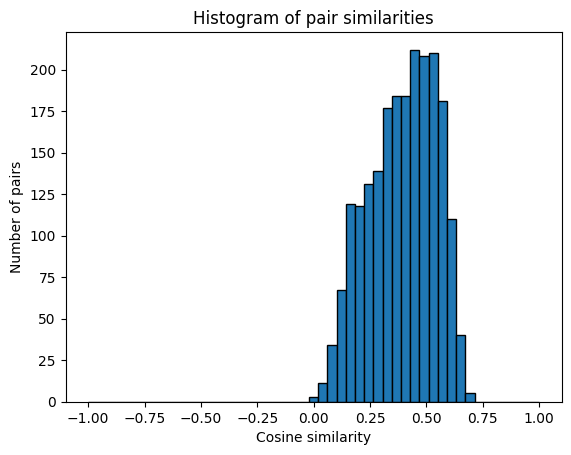

array([0.12625015, 0.47679491, 0.45507649, ..., 0.44175235, 0.13219884,
       0.62138653])

In [7]:
# Compute and plot one-to-one cossim
tg.deterministic_mapping_similarity(ad_map_vanilla, adata_sc, adata_st, 
                             flavour='spot_to_cell')

In [8]:
# Get cell-to-spot pairs dataframe
cts_df = tg.get_cell_spot_pair(ad_map_vanilla)

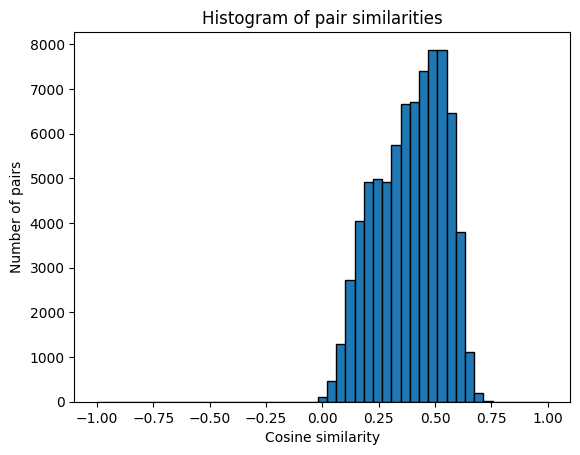

array([0.44140839, 0.34840425, 0.17213958, ..., 0.37617179, 0.52307962,
       0.60083196])

In [10]:
# Compute one-to-one cossim
tg.deterministic_mapping_similarity(ad_map_vanilla, adata_sc, adata_st, 
                             flavour='cell_to_spot')

In [11]:
# Count mathces between flavours
matches = tg.count_deterministic_mapping_matches(cts_df, stc_df)

>>> Fraction of spots that match the reverse mapping: 0.96


This last line shows that the two mappings are not one the inverse of the other. This also implies that performing a cell to spot deterministic mapping does not guaranteethat  each spot will be called and thus mapped.

## Filter mode

In [18]:
del ad_map_vanilla, mapper_vanilla, data_vanilla

In [19]:
ad_map_filt, mapper_filt, data_filt = tg.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='filter',
    learning_rate=0.1,
    num_epochs=400,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=1e-6,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-5,
    lambda_f_reg=1e-5,
    target_count=None,
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/400 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   0%|▏                                                                      | 1/400 [00:16<1:48:47, 16.36s/it]

Epoch 0: {'Total loss': 0.05066728591918945, 'Score': 0.5169240236282349, 'KL divergence': 1.3388926163315773e-05, 'Filter term': 36486.3515625}


Trainig:  25%|█████████████████▉                                                     | 101/400 [17:37<53:41, 10.77s/it]

...

Trainig:  50%|███████████████████████████████████▋                                   | 201/400 [35:09<35:53, 10.82s/it]

Epoch 200: {'Total loss': -0.30738988518714905, 'Score': 0.6155765652656555, 'KL divergence': 5.203532055020332e-06, 'Filter term': 17504.71484375}


Trainig:  75%|█████████████████████████████████████████████████████▍                 | 301/400 [53:03<17:47, 10.79s/it]

Epoch 300: {'Total loss': -0.30739063024520874, 'Score': 0.6155765652656555, 'KL divergence': 5.19677996635437e-06, 'Filter term': 17504.712890625}


Trainig: 100%|█████████████████████████████████████████████████████████████████████| 400/400 [1:10:58<00:00, 10.65s/it]


In [21]:
# Get spot-cell pairs dataframe
stc_df = tg.get_spot_cell_pair(ad_map_filt, filter=True)

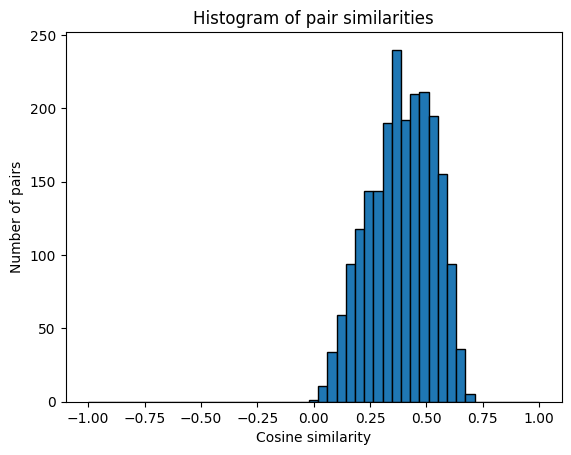

array([0.04998054, 0.49479447, 0.36146803, ..., 0.35725206, 0.13219884,
       0.60826054])

In [22]:
# Compute and plot one-to-one cossim
tg.deterministic_mapping_similarity(ad_map_filt, adata_sc, adata_st, 
                             flavour='spot_to_cell', filter=True)

In [23]:
# Get cell-to-spot pairs dataframe
cts_df = tg.get_cell_spot_pair(ad_map_filt, filter=True)

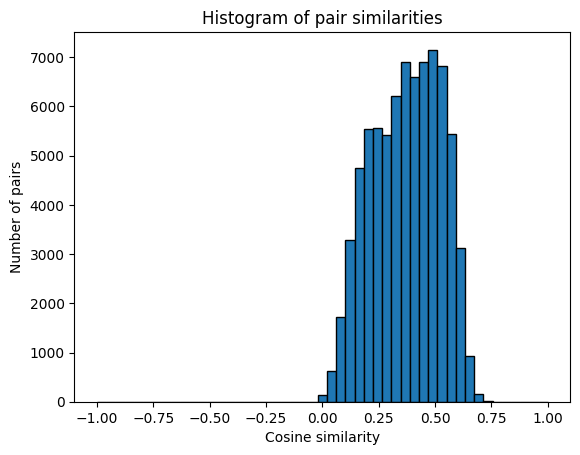

array([0.43569583, 0.34840425, 0.17213958, ..., 0.37617179, 0.52307962,
       0.53762291])

In [25]:
# Compute one-to-one cossim
tg.deterministic_mapping_similarity(ad_map_filt, adata_sc, adata_st, 
                             flavour='cell_to_spot')

In [26]:
# Count mathces between flavours
matches = tg.count_deterministic_mapping_matches(cts_df, stc_df)

>>> Fraction of spots that match the reverse mapping: 0.75


# Annotation Transfer

## Vanilla

### Tangram annotation

In [ ]:
# Transfer annotation
tg.transfer_annotation(ad_map_vanilla, adata_st, sc_cluster_label='Allen.class_label')

In [14]:
# Get classifcation report
bulk_report = tg.annotation_report(adata_st.obs['class_label'], adata_st.obs['tangram_annotation'])


Overall annotation accuracy: 0.632

Per-class annotation report:
               precision  recall  f1-score   support
GABAergic          1.000   0.930     0.964   142.000
Glutamatergic      0.920   1.000     0.959  1215.000
Non-Neuronal       0.000   0.000     0.000     0.000
Other              0.000   0.000     0.000   776.000
accuracy           0.632   0.632     0.632     0.632
macro avg          0.480   0.482     0.481  2133.000
weighted avg       0.591   0.632     0.610  2133.000


### Deterministic based annotation

In [31]:
adata_st.obs['class_label'].unique()

['Other', 'Glutamatergic', 'GABAergic']
Categories (3, object): ['GABAergic', 'Glutamatergic', 'Other']

In [16]:
# Get one-to-one annotation (returns two lists)
det_ann_true, det_ann_pred = tg.deterministic_annotation(ad_map_vanilla,
        adata_sc,
        adata_st,
        flavour='spot_to_cell',
        sc_cluster_label='Allen.class_label',
        st_cluster_label='class_label',
        )

In [17]:
# Compute classification report
det_report = tg.annotation_report(det_ann_true, det_ann_pred)


Overall annotation accuracy: 0.455

Per-class annotation report:
               precision  recall  f1-score   support
GABAergic          0.295   0.528     0.379   142.000
Glutamatergic      0.823   0.737     0.778  1215.000
Non-Neuronal       0.000   0.000     0.000     0.000
Other              0.000   0.000     0.000   776.000
accuracy           0.455   0.455     0.455     0.455
macro avg          0.280   0.316     0.289  2133.000
weighted avg       0.489   0.455     0.468  2133.000


## Filter

### Tangram annotation

In [30]:
tg.transfer_annotation(ad_map_filt, adata_st, sc_cluster_label='Allen.class_label',
                      filter=True)

In [31]:
# Get classifcation report
bulk_report = tg.annotation_report(adata_st.obs['class_label'], adata_st.obs['tangram_annotation'])


Overall annotation accuracy: 0.629

Per-class annotation report:
               precision  recall  f1-score   support
GABAergic          1.000   0.894     0.944   142.000
Glutamatergic      0.946   1.000     0.972  1215.000
Non-Neuronal       0.000   0.000     0.000     0.000
Other              0.000   0.000     0.000   776.000
accuracy           0.629   0.629     0.629     0.629
macro avg          0.487   0.474     0.479  2133.000
weighted avg       0.606   0.629     0.617  2133.000


### Determ. annotation

In [27]:
# Get one-to-one annotation (returns two lists)
det_ann_true, det_ann_pred = tg.deterministic_annotation(ad_map_filt,
        adata_sc,
        adata_st,
        flavour='spot_to_cell',
        sc_cluster_label='Allen.class_label',
        st_cluster_label='class_label',
        )

In [28]:
# Compute classification report
det_report = tg.annotation_report(det_ann_true, det_ann_pred)


Overall annotation accuracy: 0.417

Per-class annotation report:
               precision  recall  f1-score   support
GABAergic          0.252   0.458     0.325   142.000
Glutamatergic      0.762   0.678     0.718  1215.000
Non-Neuronal       0.000   0.000     0.000     0.000
Other              0.000   0.000     0.000   776.000
accuracy           0.417   0.417     0.417     0.417
macro avg          0.254   0.284     0.261  2133.000
weighted avg       0.451   0.417     0.430  2133.000


# Annotation supervision
Additionally, for technologies like MERFISH or other ISH, the spatial transcriptomics assay is performed on a limited, pre-defined set of genes.  

- It is realistic to assume that, especially for well-studied tissues, a biologically relevant panel (DE, HV, or tissue-characteristic genes) is adopted for the ST experiment.  

- This implies that, based on this restricted panel, manual or reference-based annotations can be implemented with good quality.  

- Availability of ST data annotation opens several options for higher-accuracy mapping, exploiting multimodal harmonized labels for supervision.  

- This use case remains very specific to the scenario described above, and is particularly useful for:  
  - reconstructing single-cell resolution, transcriptome-wide spatial profiles, and  
  - enabling more precise labeling and identification of subclasses or cell states.  
